Installations for CLIP MODEL

In [ ]:
model_id = "Qwen/Qwen2-VL-7B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

processor = Qwen2VLProcessor.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def generate_answer(image_path, query, max_new_tokens=256):
    image = Image.open(image_path).convert("RGB")
    sample = {
        "messages": [
            {"role": "system", "content": [{"type": "text", "text": "You are a Vision Language Model. Answer concisely."}]},
            {"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": query}]}
        ]
    }

    text_input = processor.apply_chat_template(sample['messages'][1:2], tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(sample['messages'])

    model_inputs = processor(text=[text_input], images=image_inputs, return_tensors="pt").to(device)

    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

    trimmed_generated_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)]

    output_text = processor.batch_decode(trimmed_generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)

    return output_text[0]

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving bear.jpg to bear.jpg


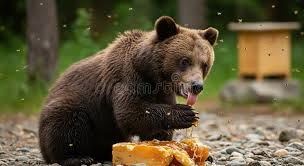

In [ ]:
from PIL import Image

image = Image.open("bear.jpg")
image

In [ ]:
sample = {
    "messages": [
        {
            "role": "system",
            "content": [
                {"type":"text",
                 "text":"You are a Vision Language Model"}
            ]
        },

        {
            "role":"user",
            "content":[
                {"type":"image","image":image},
                {"type":"text","text":"What animal is this?"}
            ]
        }
    ]
}

CLIP MODEL

In [ ]:
# Install libraries
!pip install transformers pillow torch

# Imports
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
from google.colab import files
import torch

# Load CLIP model
model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

# Upload image
uploaded = files.upload()

# Load uploaded image
image_name = list(uploaded.keys())[0]
image = Image.open(image_name)

# Possible classes (you define these)
labels = [
    "bear",
    "dog",
    "cat",
    "horse",
    "car",
    "person"
]

# Process image + text together
inputs = processor(
    text=labels,
    images=image,
    return_tensors="pt",
    padding=True
)

# Run CLIP
outputs = model(**inputs)

# Similarity scores
logits = outputs.logits_per_image

# Convert to probabilities
probs = logits.softmax(dim=1)

print("\nPrediction probabilities:\n")

for label, prob in zip(labels, probs[0]):
    print(f"{label}: {prob.item():.4f}")

predicted_class = labels[torch.argmax(probs)]

print("\nPredicted class:", predicted_class)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Saving bear.jpg to bear (1).jpg

Prediction probabilities:

bear: 0.9993
dog: 0.0006
cat: 0.0001
horse: 0.0000
car: 0.0000
person: 0.0000

Predicted class: bear


BLIP MODEL

In [ ]:
# Install
!pip install transformers pillow torch

from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
from google.colab import files

# Upload image
uploaded = files.upload()

image_name = list(uploaded.keys())[0]
image = Image.open(image_name)

# Load BLIP
processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

# Process image
inputs = processor(image, return_tensors="pt")

# Generate caption
out = model.generate(**inputs)

caption = processor.decode(
    out[0],
    skip_special_tokens=True
)

print("Generated Caption:")
print(caption)

Saving bear.jpg to bear (2).jpg


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1610: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Generated Caption:
a bear eating a piece of fruit on a rocky beach


In [ ]:
# Install dependencies
!pip install -U transformers accelerate qwen-vl-utils torch pillow

# Imports
import torch
from PIL import Image
from transformers import (
    Qwen2VLForConditionalGeneration,
    Qwen2VLProcessor
)
from qwen_vl_utils import process_vision_info
from google.colab import files

In [ ]:
model_id = "Qwen/Qwen2-VL-2B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype="auto",
    device_map="auto"
)

processor = Qwen2VLProcessor.from_pretrained(model_id)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text",
             "text": "Describe this image in detail"}
        ]
    }
]

In [ ]:
text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

image_inputs, _ = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    return_tensors="pt"
)

inputs = inputs.to(device)

generated_ids = model.generate(
    **inputs,
    max_new_tokens=80
)

generated_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)

print(generated_text[0])

system
You are a helpful assistant.
user
Describe this image in detail
assistant
The image depicts a brown bear sitting on a rocky surface, likely in a forested area. The bear appears to be in a relaxed state, possibly enjoying a meal. The bear's fur is dark brown, and it is sitting with its front paws on a piece of food, which looks like a piece of cheese or a similar type of food. The bear's eyes are wide open, and


In [ ]:
# ================================
# MINI CLIP PROJECT
# Zero-Shot Image Classification
# ================================

# Install:
# pip install transformers torch pillow requests

from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests
import torch

# ----------------------------
# Load CLIP Model
# ----------------------------

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# ----------------------------
# Load Image
# ----------------------------

# You can use your own image:
# image = Image.open("dog.jpg")

# OR use online image
url = "https://images.unsplash.com/photo-1517849845537-4d257902454a"
image = Image.open(requests.get(url, stream=True).raw)

# ----------------------------
# Candidate Text Labels
# ----------------------------

labels = [
    "a photo of a dog",
    "a photo of a cat",
    "a photo of a car",
    "a photo of a tree"
]

# ----------------------------
# Preprocess Inputs
# ----------------------------

inputs = processor(
    text=labels,
    images=image,
    return_tensors="pt",
    padding=True
)

# ----------------------------
# Forward Pass
# ----------------------------

with torch.no_grad():
    outputs = model(**inputs)

# ----------------------------
# Similarity Scores
# ----------------------------

logits_per_image = outputs.logits_per_image

# Convert to probabilities
probs = logits_per_image.softmax(dim=1)

# ----------------------------
# Print Results
# ----------------------------

print("\nPrediction Probabilities:\n")

for label, prob in zip(labels, probs[0]):
    print(f"{label}: {prob.item()*100:.2f}%")

# ----------------------------
# Final Prediction
# ----------------------------

pred_index = probs.argmax().item()

print("\nFinal Prediction:")
print(labels[pred_index])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]


Prediction Probabilities:

a photo of a dog: 99.68%
a photo of a cat: 0.29%
a photo of a car: 0.03%
a photo of a tree: 0.01%

Final Prediction:
a photo of a dog
